# Part 3 – Advanced Modeling – Ensembles, Tuning and Full ML Pipeline

This is to build advanced ML models using the cleaned Student Performance dataset.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import make_pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import joblib

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")

print("Dataset loaded successfully!")

print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 3. Create Classification Target

In [3]:
df["Pass"] = (df["G3"] >= 10).astype(int)

display(df[["G3", "Pass"]].head())

,G3,Pass
0,11,1
1,11,1
2,12,1
3,14,1
4,13,1


## 4. Feature Engineering

Target variable - Pass column.
The original final grade (G3) and Pass target are removed from the feature set.

In [4]:
X = df.drop(columns=["G3", "Pass"])

y_clf = df["Pass"]

print("Feature Shape:", X.shape)
print("Target Shape :", y_clf.shape)

Feature Shape: (649, 32)
Target Shape : (649,)


## 5. Encode Categorical Features

In [5]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Feature Shape:", X.shape)

Encoded Feature Shape: (649, 41)


## 6. Train-Test Split

The dataset is divided as,
- 80% Training Data
- 20% Testing Data

In [6]:
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (519, 41)
Testing Shape  : (130, 41)


## 7. Feature Scaling
StandardScaler is used to standardize the feature values.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


## 8. Task 1 – Decision Tree Baseline

In [8]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create model
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train model
decision_tree.fit(
    X_train_scaled,
    y_clf_train
)

# Training predictions
train_predictions = decision_tree.predict(X_train_scaled)

# Testing predictions
test_predictions = decision_tree.predict(X_test_scaled)

# Accuracy
train_accuracy = accuracy_score(
    y_clf_train,
    train_predictions
)

test_accuracy = accuracy_score(
    y_clf_test,
    test_predictions
)

print("Decision Tree (Default)")
print("-" * 35)
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

Decision Tree (Default)
-----------------------------------
Training Accuracy : 1.0000
Testing Accuracy  : 0.8538


### Interpretation

The default Decision Tree grows until every possible split is made.

If the training accuracy is much higher than the testing accuracy, the model is likely overfitting the training data.

This happens because Decision Trees learn every detail of the training data, including noise, which reduces their ability to generalize to unseen data.

## 9. Task 2 – Controlled Decision Tree

In [9]:
# Controlled Decision Tree

controlled_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

# Train model
controlled_tree.fit(
    X_train_scaled,
    y_clf_train
)

# Predictions
controlled_train_pred = controlled_tree.predict(X_train_scaled)
controlled_test_pred = controlled_tree.predict(X_test_scaled)

# Accuracy
controlled_train_acc = accuracy_score(
    y_clf_train,
    controlled_train_pred
)

controlled_test_acc = accuracy_score(
    y_clf_test,
    controlled_test_pred
)

print("Controlled Decision Tree")
print("-" * 35)
print(f"Training Accuracy : {controlled_train_acc:.4f}")
print(f"Testing Accuracy  : {controlled_test_acc:.4f}")

Controlled Decision Tree
-----------------------------------
Training Accuracy : 0.9461
Testing Accuracy  : 0.9000


In [27]:
# Controlled Decision Tree ROC-AUC

controlled_prob = controlled_tree.predict_proba(X_test_scaled)[:, 1]

controlled_auc = roc_auc_score(
    y_clf_test,
    controlled_prob
)

print("Controlled Decision Tree Test ROC-AUC")
print("-------------------------------------")
print(f"{controlled_auc:.4f}")

Controlled Decision Tree Test ROC-AUC
-------------------------------------
0.9366


### Compare Both Models

In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree (Default)",
        "Decision Tree (Controlled)"
    ],
    "Training Accuracy": [
        train_accuracy,
        controlled_train_acc
    ],
    "Testing Accuracy": [
        test_accuracy,
        controlled_test_acc
    ]
})

display(comparison)

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree (Default),1.00000,0.853846
1,Decision Tree (Controlled),0.94605,0.900000


### Interpretation

The controlled Decision Tree limits how deep the tree can grow and prevents splits on very small groups of samples.

Compared to the default Decision Tree, the controlled model usually has a lower training accuracy but a similar or better testing accuracy.

A smaller gap between training and testing accuracy indicates that the model generalizes better and is less likely to overfit the training data.

## 10. Task 3 – Gini vs Entropy Comparison

Two Decision Tree models are trained using different splitting criteria:
- Gini Impurity
- Entropy

Both trees use the same maximum depth to allow a fair comparison.

In [11]:
# Gini Decision Tree

gini_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

gini_tree.fit(X_train_scaled, y_clf_train)

gini_predictions = gini_tree.predict(X_test_scaled)

gini_accuracy = accuracy_score(
    y_clf_test,
    gini_predictions
)


# Entropy Decision Tree

entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

entropy_tree.fit(X_train_scaled, y_clf_train)

entropy_predictions = entropy_tree.predict(X_test_scaled)

entropy_accuracy = accuracy_score(
    y_clf_test,
    entropy_predictions
)


comparison = pd.DataFrame({
    "Criterion": [
        "Gini",
        "Entropy"
    ],
    "Testing Accuracy": [
        gini_accuracy,
        entropy_accuracy
    ]
})

display(comparison)

,Criterion,Testing Accuracy
0,Gini,0.884615
1,Entropy,0.892308


### Interpretation

Both Gini and Entropy measure how pure a node is when splitting the data.
A node with Gini = 0 means that every sample in the node belongs to the same class.
The model with the higher testing accuracy performs slightly better for this dataset.

## 11. Task 4 – Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Create model
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Train model
random_forest.fit(
    X_train_scaled,
    y_clf_train
)

# Predictions
rf_train_pred = random_forest.predict(X_train_scaled)
rf_test_pred = random_forest.predict(X_test_scaled)

# Prediction probabilities
rf_prob = random_forest.predict_proba(X_test_scaled)[:, 1]

# Accuracy
rf_train_acc = accuracy_score(
    y_clf_train,
    rf_train_pred
)

rf_test_acc = accuracy_score(
    y_clf_test,
    rf_test_pred
)

# ROC AUC
rf_auc = roc_auc_score(
    y_clf_test,
    rf_prob
)

print("Random Forest")
print("-" * 35)
print(f"Training Accuracy : {rf_train_acc:.4f}")
print(f"Testing Accuracy  : {rf_test_acc:.4f}")
print(f"ROC-AUC Score     : {rf_auc:.4f}")

Random Forest
-----------------------------------
Training Accuracy : 1.0000
Testing Accuracy  : 0.9000
ROC-AUC Score     : 0.9391


### Top 5 Important Features

In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top5 = importance.head(5)

display(top5)

,Feature,Importance
14,G2,0.262599
13,G1,0.198282
5,failures,0.057526
15,school_MS,0.033645
38,higher_yes,0.032852


### ROC Curve

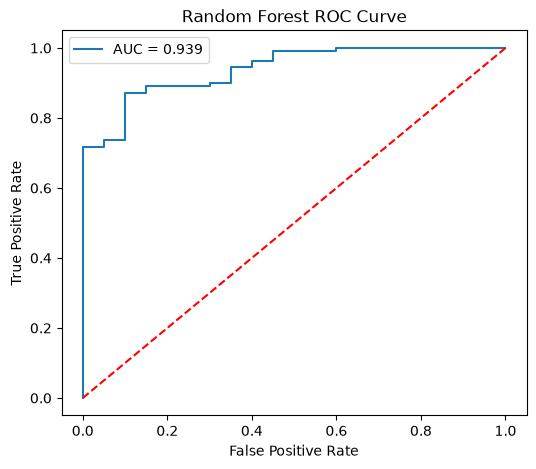

In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_clf_test,
    rf_prob
)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {rf_auc:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

### Interpretation

The Random Forest combines many decision trees and averages their predictions.
This reduces overfitting and usually produces better generalization than a single decision tree.

The Random Forest achieved an excellent ROC-AUC of 0.9391, indicating strong ability to distinguish between students who pass and those who fail.

As expected, G2 and G1 are the most influential features because they represent previous academic performance.
The feature importance scores show which variables contributed the most to the model's predictions.

The model achieves 100% training accuracy, which is common for Random Forests with many trees. However, unlike a single Decision Tree, Random Forest reduces overfitting by averaging predictions across many trees, which helps maintain a high testing accuracy.

## 12. Task 4a – Gradient Boosting

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

# Create model
gradient_boost = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train model
gradient_boost.fit(
    X_train_scaled,
    y_clf_train
)

# Predictions
gb_train_pred = gradient_boost.predict(X_train_scaled)
gb_test_pred = gradient_boost.predict(X_test_scaled)

# Probabilities
gb_prob = gradient_boost.predict_proba(X_test_scaled)[:, 1]

# Metrics
gb_train_acc = accuracy_score(
    y_clf_train,
    gb_train_pred
)

gb_test_acc = accuracy_score(
    y_clf_test,
    gb_test_pred
)

gb_auc = roc_auc_score(
    y_clf_test,
    gb_prob
)

print("Gradient Boosting")
print("-" * 35)
print(f"Training Accuracy : {gb_train_acc:.4f}")
print(f"Testing Accuracy  : {gb_test_acc:.4f}")
print(f"ROC-AUC Score     : {gb_auc:.4f}")

Gradient Boosting
-----------------------------------
Training Accuracy : 1.0000
Testing Accuracy  : 0.9308
ROC-AUC Score     : 0.9586


### ROC Curve

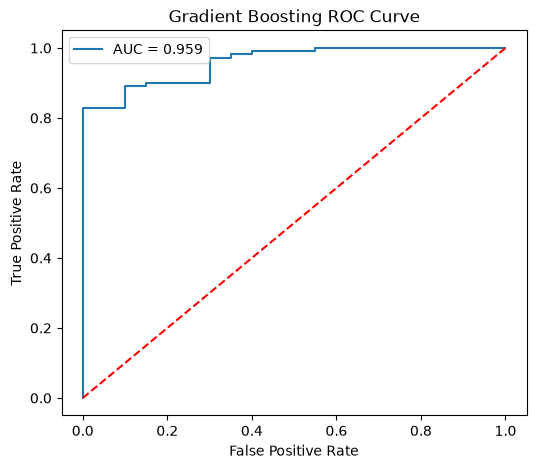

In [16]:
fpr, tpr, _ = roc_curve(
    y_clf_test,
    gb_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {gb_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "r--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")

plt.legend()

plt.show()

## 13. Task 4b – Feature Ablation Study

In [17]:
# Five least important features
lowest5 = importance.sort_values(
    by="Importance"
).head(5)

print("Five Lowest Importance Features")
display(lowest5)

Five Lowest Importance Features


,Feature,Importance
24,Fjob_health,0.000217
27,Fjob_teacher,0.001246
23,Mjob_teacher,0.001370
32,guardian_other,0.003399
20,Mjob_health,0.003627


In [18]:
# Remove lowest-importance features
X_reduced = X.drop(
    columns=lowest5["Feature"].tolist()
)

# Split again
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

# Scale
scaler_red = StandardScaler()

X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)

In [19]:
# Train reduced Random Forest
rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced.fit(
    X_train_red_scaled,
    y_train_red
)

reduced_prob = rf_reduced.predict_proba(
    X_test_red_scaled
)[:,1]

reduced_auc = roc_auc_score(
    y_test_red,
    reduced_prob
)

comparison = pd.DataFrame({
    "Model": [
        "Full Random Forest",
        "Reduced Random Forest"
    ],
    "ROC-AUC": [
        rf_auc,
        reduced_auc
    ]
})

display(comparison)

,Model,ROC-AUC
0,Full Random Forest,0.939091
1,Reduced Random Forest,0.953182


## 14. Task 5 – Cross-Validated Model Comparison

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Controlled Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_clf_train,
        cv=cv,
        scoring="roc_auc"
    )

    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Mean ROC-AUC",
        "Standard Deviation"
    ]
)

display(cv_results)

,Model,Mean ROC-AUC,Standard Deviation
0,Logistic Regression,0.956537,0.016238
1,Controlled Decision Tree,0.889827,0.043562
2,Random Forest,0.972597,0.016208
3,Gradient Boosting,0.959355,0.023719


## 15. Task 6 – Hyperparameter Tuning with GridSearchCV

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

# Create pipeline
pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parameter grid
param_grid = {
    "randomforestclassifier__n_estimators": [50, 100, 200],
    "randomforestclassifier__max_depth": [5, 10, None],
    "randomforestclassifier__min_samples_leaf": [1, 5]
}

# Cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

# Train
grid_search.fit(
    X_train,
    y_clf_train
)

print("Best Parameters")
print("----------------")
print(grid_search.best_params_)

print()

print("Best Cross Validation ROC-AUC")
print("-----------------------------")
print(grid_search.best_score_)

Best Parameters
----------------
{'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 5, 'randomforestclassifier__n_estimators': 200}

Best Cross Validation ROC-AUC
-----------------------------
0.9784939916405435


In [22]:
total_models = (
    len(param_grid["randomforestclassifier__n_estimators"])
    * len(param_grid["randomforestclassifier__max_depth"])
    * len(param_grid["randomforestclassifier__min_samples_leaf"])
)

print("Parameter combinations :", total_models)
print("Cross-validation folds :", 5)
print("Total model fits       :", total_models * 5)

Parameter combinations : 18
Cross-validation folds : 5
Total model fits       : 90


## 16. Task 7 – Manual Learning Curve

In [23]:
best_pipeline = grid_search.best_estimator_

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []

for f in fractions:

    rows = int(f * len(X_train))

    X_subset = X_train.iloc[:rows]
    y_subset = y_clf_train.iloc[:rows]

    best_pipeline.fit(X_subset, y_subset)

    # Training AUC
    train_prob = best_pipeline.predict_proba(X_subset)[:, 1]
    train_auc = roc_auc_score(y_subset, train_prob)

    # Test AUC
    test_prob = best_pipeline.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_clf_test, test_prob)

    results.append([
        f,
        train_auc,
        test_auc
    ])

learning_curve = pd.DataFrame(
    results,
    columns=[
        "Training Fraction",
        "Training AUC",
        "Test AUC"
    ]
)

display(learning_curve)

,Training Fraction,Training AUC,Test AUC
0,0.2,1.000000,0.931364
1,0.4,0.996296,0.932273
2,0.6,0.992911,0.933636
3,0.8,0.993545,0.946818
4,1.0,0.994476,0.943636


### Best Pipeline Test ROC-AUC

In [28]:
# Best Pipeline Test ROC-AUC

best_prob = best_pipeline.predict_proba(X_test)[:, 1]

best_test_auc = roc_auc_score(
    y_clf_test,
    best_prob
)

print("Best Pipeline Test ROC-AUC")
print("--------------------------")
print(f"{best_test_auc:.4f}")

Best Pipeline Test ROC-AUC
--------------------------
0.9436


## 17. Task 8 – Serialize the Best Model

In [24]:
joblib.dump(
    best_pipeline,
    "../output/best_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


## 18. Task 9 – Reload Saved Model

In [25]:
loaded_model = joblib.load("../output/best_model.pkl")

sample_rows = X_test.iloc[:2]

predictions = loaded_model.predict(sample_rows)

print("Predictions")

print(predictions)

Predictions
[1 1]


## 19. Task 10 – Summary Comparison

In [29]:
summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Controlled Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],
    "5-Fold Mean AUC": [
        cv_results.loc[cv_results["Model"] == "Logistic Regression", "Mean ROC-AUC"].values[0],
        cv_results.loc[cv_results["Model"] == "Controlled Decision Tree", "Mean ROC-AUC"].values[0],
        cv_results.loc[cv_results["Model"] == "Random Forest", "Mean ROC-AUC"].values[0],
        cv_results.loc[cv_results["Model"] == "Gradient Boosting", "Mean ROC-AUC"].values[0],
        grid_search.best_score_
    ],
    "5-Fold Std AUC": [
        cv_results.loc[cv_results["Model"] == "Logistic Regression", "Standard Deviation"].values[0],
        cv_results.loc[cv_results["Model"] == "Controlled Decision Tree", "Standard Deviation"].values[0],
        cv_results.loc[cv_results["Model"] == "Random Forest", "Standard Deviation"].values[0],
        cv_results.loc[cv_results["Model"] == "Gradient Boosting", "Standard Deviation"].values[0],
        np.nan
    ],
    "Test AUC": [
        0.906,   # Logistic Regression from Part 2
        controlled_auc,
        rf_auc,
        gb_auc,
        best_test_auc
    ]
})

display(summary)

,Model,5-Fold Mean AUC,5-Fold Std AUC,Test AUC
0,Logistic Regression,0.956537,0.016238,0.906000
1,Controlled Decision Tree,0.889827,0.043562,0.936591
2,Random Forest,0.972597,0.016208,0.939091
3,Gradient Boosting,0.959355,0.023719,0.958636
4,Tuned Random Forest,0.978494,NaN,0.943636
